# osapiens Challenge Makeathon 2026 — Detecting Deforestation from Space

---

## Table of Contents

1. Data Download / Structure / Setup
2. Challenge: Detecting Deforestation from Space
3. Definition of Deforestation
4. Data Description & Visualisation
   - 4.1 Sentinel-2
   - 4.2 Sentinel-1
   - 4.3 AlphaEarth Foundations
5. Labels Description & Visualisation
   - 5.1 RADD Alert Labels
   - 5.2 GLAD-L Alert Labels
   - 5.3 GLAD-S2 Alert Labels
6. Submission
   - 6.1 Example: using `submission_utils.py`
7. Helpful Resources

## 1 — Data Download / Structure / Setup

> run `make download_data_from_s3` from your terminal to download data

After downloading, the dataset lives under `data/makeathon-challenge/` and is split into `train` and `test` sets across four top-level folders.

```
data/makeathon-challenge/
├── sentinel-1/
│   ├── train/{tile_id}__s1_rtc/{tile_id}__s1_rtc_{year}_{month}_{ascending|descending}.tif
│   └── test/  ...
├── sentinel-2/
│   ├── train/{tile_id}__s2_l2a/{tile_id}__s2_l2a_{year}_{month}.tif
│   └── test/  ...
├── aef-embeddings/
│   ├── train/{tile_id}_{year}.tiff
│   └── test/  ...
├── labels/train/
│   ├── gladl/   gladl_{tile_id}_alert{YY}.tif  +  gladl_{tile_id}_alertDate{YY}.tif
│   ├── glads2/  glads2_{tile_id}_alert.tif     +  glads2_{tile_id}_alertDate.tif
│   └── radd/    radd_{tile_id}_labels.tif
└── metadata/
    ├── train_tiles.geojson
    └── test_tiles.geojson
```

Each tile is identified by an ID of the form `{MGRS_grid}_{x}_{y}` (e.g. `18NWG_6_6`), encoding its position within a Military Grid Reference System tile. Sentinel-1 and Sentinel-2 are monthly time series; AlphaEarth embeddings are annual. Labels are only provided for the training set — the test set is used exclusively for leaderboard evaluation. Spatial coverage of all tiles is documented in the two GeoJSON files under `metadata/`.

**We want to emphasize that you are not required to use these specific data sources or labels in your solution.** You are free to incorporate any additional data sources or labels you find useful, as long as your final submission follows the required format and contains predictions only for the test set tiles. More on submission format in section 6.

## 2 — Challenge: Detecting Deforestation from Space

![deforestation](content/deforestation.png)
> The picture above shows a deforestation event in the Cerrado Region, Brazil captured by Sentinel-2 in September 2020.

As global deforestation continues, the EU Deforestation Regulation (EUDR) is driving demand for large-scale geospatial monitoring by requiring companies to verify that their supply chains are deforestation-free.

Satellite constellations monitor Earth at global scale using optical and radar sensors—but turning this data into reliable insights is difficult.

Satellite data is noisy, heterogeneous, and varies across sensors, regions, and environmental conditions.

As a result, deforestation detection systems often lack accuracy and generalization.

Building systems that can turn these imperfect signals into reliable, automated, and globally consistent evidence remains an open problem and the focus of this challenge.



## 3 — Definition of Deforestation

For this challenge, we focus exclusively on deforestation events occurring after 2020. Deforestation is defined as the permanent removal of tree cover, leading to a transition from forest to non-forest land. Accordingly, an event is only considered deforestation after 2020 if the area was forest in 2020.

## 4 — Data Description & Visualisation

In this challenge we have 3 data modalities (Sentinel-2, Sentinel-1, and AlphaEarth Foundations) and 3 weak-label sources (RADD, GLAD-L, and GLAD-S2). Each has different characteristics, strengths, and limitations. Understanding these is crucial for building effective models. In the sections below, we provide an overview of each data source, along with code snippets to load and visualize the data.

### 4.1 — Sentinel-2

Each pixel in the Sentinel-2 data contains 12 spectral bands, each capturing reflectance at different wavelengths. These bands provide complementary information about land cover, vegetation health, soil properties, and atmospheric conditions. Below is a summary of the Sentinel-2 bands included in the dataset:

| Band | Name / Type | Resolution (m/px) | Central Wavelength (nm) | Bandwidth (nm) | Description / Use |
|------|------------|-------------------|--------------------------|----------------|-------------------|
| B01 | Aerosol | 60 | 443 | 20 | Aerosol detection |
| B02 | Blue | 10 | 490 | 65 | Soil & vegetation discrimination, forest mapping, detects man-made features |
| B03 | Green | 10 | 560 | 35 | Water clarity contrast, vegetation reflectance, highlights oil |
| B04 | Red | 10 | 665 | 30 | Vegetation, soil, urban areas, strong reflection from dead foliage |
| B05 | Red Edge | 20 | 705 | 15 | Vegetation classification |
| B06 | Red Edge | 20 | 740 | 15 | Vegetation classification |
| B07 | Red Edge | 20 | 783 | 20 | Vegetation classification |
| B08 | NIR | 10 | 842 | 115 | Biomass, vegetation analysis, shoreline mapping |
| B8A | Narrow NIR | 20 | 865 | 20 | Vegetation classification |
| B09 | Water Vapour | 60 | 945 | 20 | Water vapour detection |
| B10 | Cirrus | 60 | 1375 | 30 | Cirrus cloud detection |
| B11 | SWIR 1 | 20 | 1610 | 90 | Moisture content, vegetation contrast, snow vs cloud differentiation |
| B12 | SWIR 2 | 20 | 2190 | 180 | Moisture content, vegetation contrast, snow vs cloud differentiation |

Source: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/bands/

All bands are provided in a single multi-band `.tif` file and are upsampled to 10m resolution for consistency. The data is delivered in a local UTM projected CRS. Observations are not mosaicked and represent the single best cloud-free scene for a given month. When combining with other rasters (e.g. labels), ensure all files are reprojected to the same CRS to guarantee proper alignment.

In [1]:
import numpy as np
import rasterio

S2_PATH    = "makeathon-challenge/sentinel-2/train/18NWG_6_6__s2_l2a/18NWG_6_6__s2_l2a_2020_1.tif"
ALERT_PATH = "makeathon-challenge/labels/train/glads2/glads2_18NWG_6_6_alert.tif"

with rasterio.open(S2_PATH) as src:
    print("Tile: 18NWG_6_6 | Year: 2020 | Month: January")
    print(f"Number of bands : {src.count}")  # all 12 spectral bands present; we render only RGB (B4, B3, B2)
    print(f"Dtype           : {src.dtypes[0]}")
    print(f"CRS             : {src.crs}")
    print(f"Shape           : {src.shape}")


Tile: 18NWG_6_6 | Year: 2020 | Month: January
Number of bands : 12
Dtype           : uint16
CRS             : EPSG:32618
Shape           : (1002, 1002)


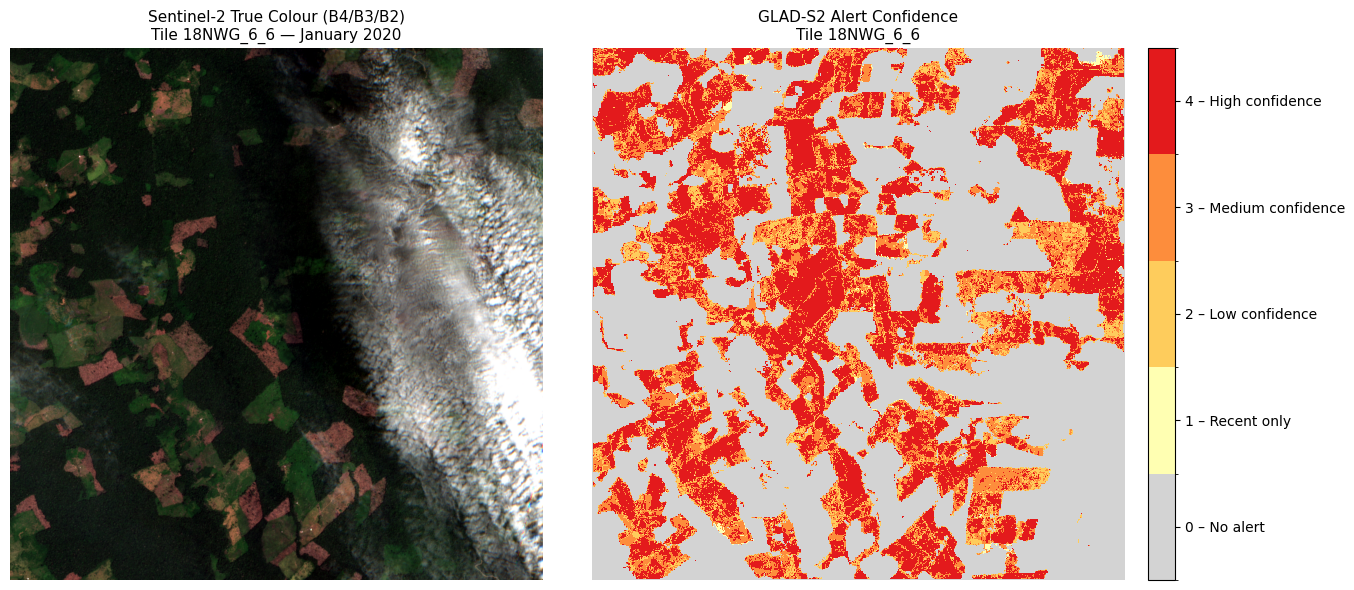

In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from rasterio.warp import reproject, Resampling

# Load Sentinel-2 RGB bands: B4 = Red (index 4), B3 = Green (index 3), B2 = Blue (index 2)
with rasterio.open(S2_PATH) as src:
    red   = src.read(4).astype(np.float32)
    green = src.read(3).astype(np.float32)
    blue  = src.read(2).astype(np.float32)
    s2_transform = src.transform
    s2_crs       = src.crs
    s2_shape     = src.shape

def percentile_normalise(band, p_lo=2, p_hi=98):
    valid = band[band > 0]
    lo, hi = np.percentile(valid, [p_lo, p_hi])
    return np.clip((band - lo) / (hi - lo + 1e-6), 0, 1)

rgb = np.stack(
    [percentile_normalise(red), percentile_normalise(green), percentile_normalise(blue)],
    axis=-1,
)

# Reproject GLAD-S2 alert (EPSG:4326) onto the Sentinel-2 grid (UTM)
with rasterio.open(ALERT_PATH) as src:
    alert_reproj = np.zeros(s2_shape, dtype=np.uint8)
    reproject(
        source=src.read(1),
        destination=alert_reproj,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=s2_transform,
        dst_crs=s2_crs,
        resampling=Resampling.nearest,
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(rgb)
axes[0].set_title("Sentinel-2 True Colour (B4/B3/B2)\nTile 18NWG_6_6 — January 2020", fontsize=11)
axes[0].axis("off")

cmap = mcolors.ListedColormap(["#d3d3d3", "#ffffb2", "#fecc5c", "#fd8d3c", "#e31a1c"])
norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)

im = axes[1].imshow(alert_reproj, cmap=cmap, norm=norm, interpolation="nearest")
axes[1].set_title("GLAD-S2 Alert Confidence\nTile 18NWG_6_6", fontsize=11)
axes[1].axis("off")

cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, ticks=[0, 1, 2, 3, 4])
cbar.ax.set_yticklabels(
    ["0 – No alert", "1 – Recent only", "2 – Low confidence", "3 – Medium confidence", "4 – High confidence"]
)

plt.tight_layout()
plt.show()


### 4.2 — Sentinel-1

Sentinel-1 is a radar satellite that provides all-weather (can penetrate clouds), day-and-night imaging capabilities. It captures the Earth's surface using microwave signals, which are reflected back to the satellite. The dataset includes 1 radar backscatter channel with VV polarisation. You can read more about Sentinel-1 Mission here: https://sentiwiki.copernicus.eu/web/s1-mission

Sentinel-1 data is available at multiple processing levels. For this challenge, we provide the highest standard: **Radiometrically Terrain Corrected (RTC)** product. Measurements have been preprocessed to correct for terrain-induced distortions and radiometric effects, making them ready for direct analysis and modeling.

The data is delivered in a local UTM projected coordinate reference system (CRS), aligned with Sentinel-2. When combining these data with other rasters (e.g., labels), ensure that all datasets are reprojected to the same CRS to guarantee proper spatial alignment.


In [3]:
S1_PATH = "makeathon-challenge/sentinel-1/train/18NWG_6_6__s1_rtc/18NWG_6_6__s1_rtc_2020_10_ascending.tif"

with rasterio.open(S1_PATH) as src:
    print("Tile: 18NWG_6_6 | Year: 2020 | Month: October | Orbit: ascending")
    print(f"Number of bands : {src.count}")  # 1 band — VV polarisation (linear scale)
    print(f"Dtype           : {src.dtypes[0]}")
    print(f"CRS             : {src.crs}")
    print(f"Shape           : {src.shape}")


Tile: 18NWG_6_6 | Year: 2020 | Month: October | Orbit: ascending
Number of bands : 1
Dtype           : float32
CRS             : EPSG:32618
Shape           : (334, 335)


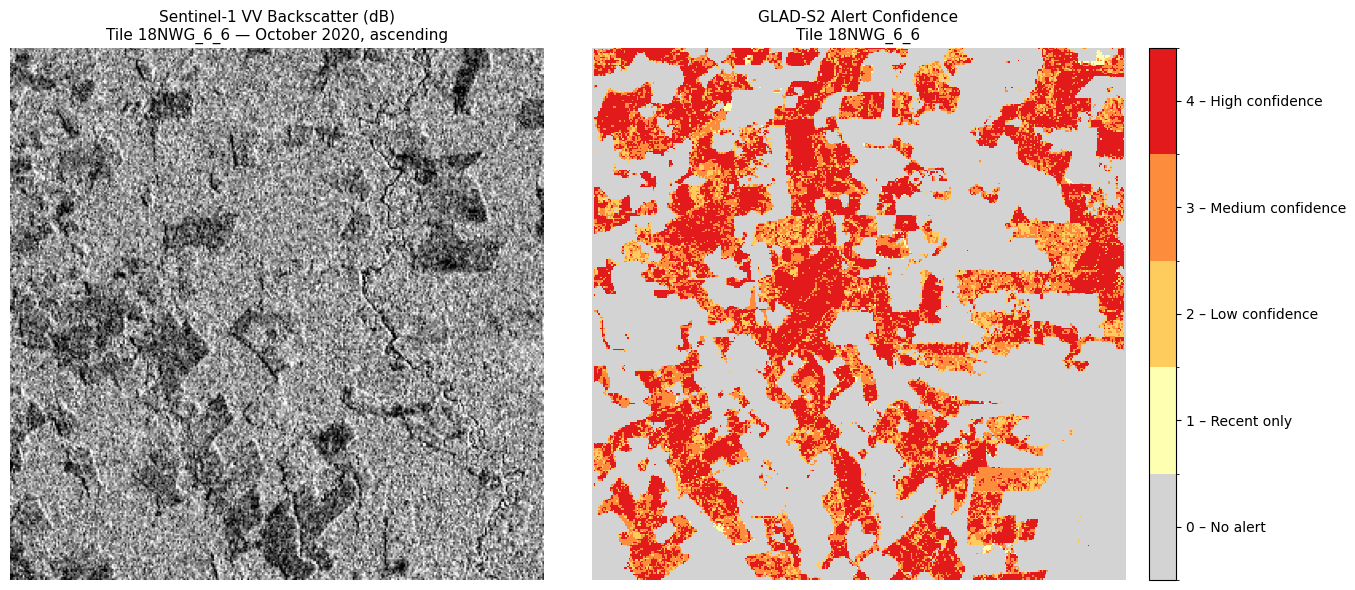

In [4]:
with rasterio.open(S1_PATH) as src:
    backscatter  = src.read(1).astype(np.float32)
    s1_transform = src.transform
    s1_crs       = src.crs
    s1_shape     = src.shape

# Convert linear backscatter to dB and normalise for display
db = np.where(backscatter > 0, 10 * np.log10(backscatter), np.nan)
valid = db[np.isfinite(db)]
lo, hi = np.percentile(valid, [2, 98])
s1_display = np.nan_to_num(np.clip((db - lo) / (hi - lo + 1e-6), 0, 1), nan=0.0)

# Reproject GLAD-S2 alert onto the S1 grid
with rasterio.open(ALERT_PATH) as src:
    alert_s1 = np.zeros(s1_shape, dtype=np.uint8)
    reproject(
        source=src.read(1),
        destination=alert_s1,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=s1_transform,
        dst_crs=s1_crs,
        resampling=Resampling.nearest,
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(s1_display, cmap="gray")
axes[0].set_title("Sentinel-1 VV Backscatter (dB)\nTile 18NWG_6_6 — October 2020, ascending", fontsize=11)
axes[0].axis("off")

cmap_alert = mcolors.ListedColormap(["#d3d3d3", "#ffffb2", "#fecc5c", "#fd8d3c", "#e31a1c"])
norm_alert = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap_alert.N)

im = axes[1].imshow(alert_s1, cmap=cmap_alert, norm=norm_alert, interpolation="nearest")
axes[1].set_title("GLAD-S2 Alert Confidence\nTile 18NWG_6_6", fontsize=11)
axes[1].axis("off")

cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, ticks=[0, 1, 2, 3, 4])
cbar.ax.set_yticklabels(
    ["0 – No alert", "1 – Recent only", "2 – Low confidence", "3 – Medium confidence", "4 – High confidence"]
)

plt.tight_layout()
plt.show()


### 4.3 — AlphaEarth Foundations (EPSG:4326)

AlphaEarth Foundations is a global dataset of pre-trained embeddings derived from multiple satellite data sources, including Sentinel-2 and Sentinel-1. These embeddings are designed to capture rich spatio-temporal patterns in the data, providing a powerful representation for downstream tasks like deforestation detection.

The dataset is organized into tiles that cover the same spatial extent as the Sentinel-2 and Sentinel-1 data, but is delivered in a geodetic coordinate reference system (CRS) of EPSG:4326 (WGS-84). This means that the pixel coordinates are defined in terms of latitude and longitude, rather than projected coordinates like UTM. When using the AlphaEarth Foundations embeddings in conjunction with the Sentinel-2 and Sentinel-1 data, it is crucial to reproject the embeddings to the same CRS (local UTM) to ensure proper spatial alignment before modeling. This can be done using geospatial libraries such as `rasterio` or `GDAL`, which allow for efficient reprojection of raster data while preserving the integrity of the embeddings.


Paper: https://arxiv.org/abs/2507.22291


In [5]:
AEF_PATH = "makeathon-challenge/aef-embeddings/train/18NWG_6_6_2020.tiff"

with rasterio.open(AEF_PATH) as src:
    print("Tile: 18NWG_6_6 | Year: 2020")
    print(f"Number of bands : {src.count}")  # 64 embedding dimensions; we display 3 randomly chosen bands as RGB
    print(f"Dtype           : {src.dtypes[0]}")
    print(f"CRS             : {src.crs}")
    print(f"Shape           : {src.shape}")


Tile: 18NWG_6_6 | Year: 2020
Number of bands : 64
Dtype           : float32
CRS             : EPSG:4326
Shape           : (1004, 998)


Randomly selected bands (1-indexed): [6, 42, 49]


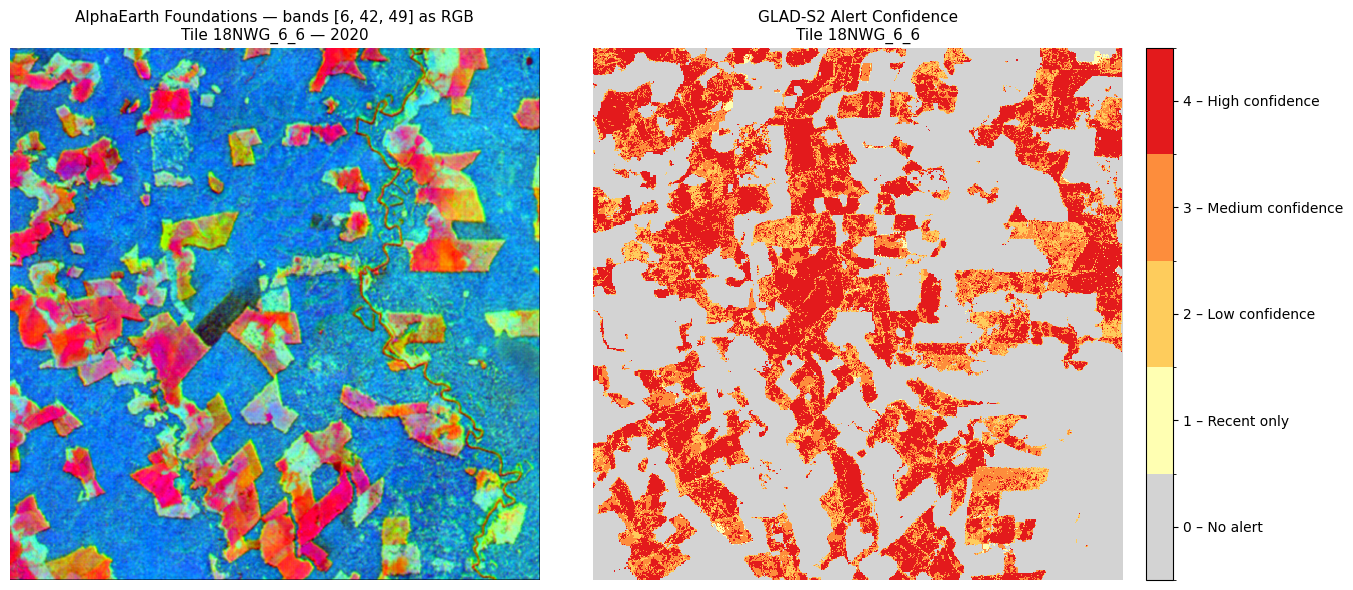

In [6]:
rng = np.random.default_rng(seed=42)
chosen = sorted(rng.choice(64, size=3, replace=False).tolist())
print(f"Randomly selected bands (1-indexed): {[b + 1 for b in chosen]}")

with rasterio.open(AEF_PATH) as src:
    aef_data     = src.read([b + 1 for b in chosen]).astype(np.float32)
    aef_transform = src.transform
    aef_crs       = src.crs
    aef_shape     = src.shape

def normalise_nan(band, p_lo=2, p_hi=98):
    valid = band[np.isfinite(band)]
    lo, hi = np.percentile(valid, [p_lo, p_hi])
    return np.nan_to_num(np.clip((band - lo) / (hi - lo + 1e-6), 0, 1), nan=0.0)

aef_rgb = np.stack([normalise_nan(aef_data[i]) for i in range(3)], axis=-1)

# Both AEF and GLAD-S2 are in EPSG:4326 — resample alert onto the AEF grid
with rasterio.open(ALERT_PATH) as src:
    alert_aef = np.zeros(aef_shape, dtype=np.uint8)
    reproject(
        source=src.read(1),
        destination=alert_aef,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=aef_transform,
        dst_crs=aef_crs,
        resampling=Resampling.nearest,
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(aef_rgb)
axes[0].set_title(
    f"AlphaEarth Foundations — bands {[b + 1 for b in chosen]} as RGB\nTile 18NWG_6_6 — 2020",
    fontsize=11,
)
axes[0].axis("off")

cmap_alert = mcolors.ListedColormap(["#d3d3d3", "#ffffb2", "#fecc5c", "#fd8d3c", "#e31a1c"])
norm_alert = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap_alert.N)

im = axes[1].imshow(alert_aef, cmap=cmap_alert, norm=norm_alert, interpolation="nearest")
axes[1].set_title("GLAD-S2 Alert Confidence\nTile 18NWG_6_6", fontsize=11)
axes[1].axis("off")

cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, ticks=[0, 1, 2, 3, 4])
cbar.ax.set_yticklabels(
    ["0 – No alert", "1 – Recent only", "2 – Low confidence", "3 – Medium confidence", "4 – High confidence"]
)

plt.tight_layout()
plt.show()


## 5 — Labels Description and Encodings

The challenge includes three sources of weak\* labels for deforestation: RADD, GLAD-L, and GLAD-S2. Each label source has different characteristics, strengths, and limitations. Below we provide an overview of each label type, along with code snippets to load and visualize the labels.

\*By weak labels, we mean that these are not perfect ground truth (predictions in fact), but rather noisy indicators of deforestation events. They can be used for training and evaluation, but it's important to understand their limitations and potential biases when interpreting model performance.


### 5.1 — RADD (Radar for Detecting Deforestation) Alert Labels

RADD is a state-of-the-art deforestation detection system that uses Sentinel-1 radar data to identify deforestation events. RADD generates binary alert masks indicating areas of potential deforestation, along with confidence scores for each alert.

We provide the alerts in it's rawest form meaning there was no post-processing was done from our side.

Here is everything you should know to understand the RADD labels:

Source files:

- one raw tile TIFF per dataset tile

Encoding:

- one integer encodes both confidence and alert date
- leading digit:
    - `2` = low confidence
    - `3` = high confidence
- remaining digits:
    - number of days since `2014-12-31`
- `0` = no alert

Examples:

- `20001` = low-confidence alert on `2015-01-01`
- `30055` = high-confidence alert on `2015-02-24`
- `21847` = low-confidence alert on `2020-01-21`


### 5.2 — GLAD-L (Global Land Analysis & Discovery — Landsat) Alert Labels

GLAD-L is a deforestation alert system that uses Landsat optical data to identify potential deforestation events. Similar to RADD, GLAD-L generates binary alert masks and alert-date rasters, but with different confidence encoding and known limitations.

Here is everything you should know to understand the GLAD-L labels:

Source files:

- `alertYY.tif`
- `alertDateYY.tif`

Examples:

- `alert24.tif`
- `alertDate24.tif`

Encoding:

- `alertYY` is a raw yearly alert raster, usually `uint8`
    - `0` = no loss
    - `2` = probable loss
    - `3` = confirmed loss
- `alertDateYY` is a raw yearly alert-date raster, usually `uint16`
    - value = day-of-year within year `20YY`
    - `0` = no alert

### 5.3 — GLAD-S2 (Global Land Analysis & Discovery — Sentinel-2) Alert Labels

GLAD-S2 is a deforestation alert system that uses Sentinel-2 optical data to identify potential deforestation events. It provides similar outputs to GLAD-L, but with different confidence encoding and known limitations.

Here is everything you should know to understand the GLAD-S2 labels:

Source files:

- `alert.tif`
- `alertDate.tif`

Encoding:

- `alert` is a raw confidence raster, usually `uint8`
    - `0` = no loss
    - `1` = loss detected only in the most recent observation
    - `2` = low confidence loss
    - `3` = medium confidence loss
    - `4` = high confidence loss
- `alertDate` is a raw day-offset raster, usually `uint16`
    - value = number of days since `2019-01-01`
    - `0` = no alert

*Note*: Compared to GLAD-L, GLAD-S2 includes all years in a single raster that is why YY is not included in the file names.

## 6 — Submission


### 6.1 — Example: using `submission_utils.py`

> Walk-through of how to convert a binary prediction raster into the submittable format using the provided utility script.

## 7 — Helpful Resources

- QGIS for desktop visualization of the rasters (.tif files) or polygons (.geojson files)
- Python libraries: Geopandas (vector data), Rasterio (raster data)

In [7]:
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling

def get_aligned_data(source_path, template_meta):
    """
    Reprojects any satellite or label file to match a template's 
    grid, CRS, and resolution.
    """
    with rasterio.open(source_path) as src:
        # Create an empty array with the template's shape (height, width)
        aligned_array = np.zeros((template_meta['height'], template_meta['width']), 
                                 dtype=src.dtypes[0])
        
        reproject(
            source=src.read(1),
            destination=aligned_array,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=template_meta['transform'],
            dst_crs=template_meta['crs'],
            resampling=Resampling.nearest, # Best for labels/categories
        )
        return aligned_array

In [8]:
import numpy as np, rasterio, glob, os
from rasterio.warp import reproject, Resampling

TRAIN_S2_DIR = "makeathon-challenge/sentinel-2/train"
train_tiles  = sorted([f.split("__")[0] for f in os.listdir(TRAIN_S2_DIR) if f.endswith("__s2_l2a")])


PATCH_SIZE = 256    # larger patches = more spatial context for U-Net
STRIDE     = 128    # 50% overlap
YEAR_PAIRS = [("2020","2021"),("2020","2022"),("2020","2023"),("2020","2024"),
              ("2021","2023"),("2021","2024"),("2022","2024")]

patches_X, patches_y = [], []

def read_s2_12bands(path, meta):
    out = np.zeros((12, meta['height'], meta['width']), dtype=np.float32)
    with rasterio.open(path) as src:
        for i in range(12):
            reproject(source=src.read(i+1), destination=out[i],
                src_transform=src.transform, src_crs=src.crs,
                dst_transform=meta['transform'], dst_crs=meta['crs'],
                resampling=Resampling.bilinear)
    return (out / 10000.0).clip(0, 1)

def extract_patches(image, mask, size, stride):
    px, py = [], []
    _, H, W = image.shape
    for r in range(0, H - size + 1, stride):
        for c in range(0, W - size + 1, stride):
            p_img  = image[:, r:r+size, c:c+size]
            p_mask = mask[r:r+size, c:c+size]
            if np.sum(p_mask) > 5:  # only patches that contain real deforestation
                px.append(p_img)
                py.append(p_mask)
    return px, py

print("🔨 Building patch dataset...")
total_def_patches = 0

for tile_id in train_tiles:
    s2_folder = f"makeathon-challenge/sentinel-2/train/{tile_id}__s2_l2a"
    all_tifs = sorted(glob.glob(s2_folder + "/*.tif"))
    if not all_tifs:
        continue

    try:
        with rasterio.open(all_tifs[0]) as src:
            meta = src.meta

        # Load labels ONCE per tile
        radd  = get_aligned_data(f"makeathon-challenge/labels/train/radd/radd_{tile_id}_labels.tif", meta)
        gladl = get_aligned_data(f"makeathon-challenge/labels/train/gladl/gladl_{tile_id}_alert24.tif", meta)
        gp = f"makeathon-challenge/labels/train/glads2/glads2_{tile_id}_alert.tif"
        glads2 = get_aligned_data(gp, meta) if os.path.exists(gp) else np.zeros_like(radd)
        raw_label = ((radd >= 20000) | (glads2 >= 2) | (gladl >= 2)).astype(np.uint8)

        s1_folder = f"makeathon-challenge/sentinel-1/train/{tile_id}__s1_rtc"

        for yr_bef, yr_aft in YEAR_PAIRS:
            bef_files = sorted(glob.glob(s2_folder + f"/*_{yr_bef}_*.tif"))
            aft_files = sorted(glob.glob(s2_folder + f"/*_{yr_aft}_*.tif"))
            if not bef_files or not aft_files:
                continue

            bef = read_s2_12bands(bef_files[0], meta)  # (12, H, W)
            aft = read_s2_12bands(aft_files[0], meta)  # (12, H, W)

            # Compute delta channels
            ndvi_bef = (bef[7] - bef[3]) / (bef[7] + bef[3] + 1e-6)
            ndvi_aft = (aft[7] - aft[3]) / (aft[7] + aft[3] + 1e-6)
            delta_ndvi = (ndvi_bef - ndvi_aft)[np.newaxis]          # (1,H,W)
            delta_swir = (aft[10] - bef[10])[np.newaxis]            # (1,H,W)

            # 26-channel image: 12 before + 12 after + delta_ndvi + delta_swir
            image = np.concatenate([bef, aft, delta_ndvi, delta_swir], axis=0)  # (26,H,W)

            # Forest filter on labels
            was_forest = (ndvi_bef > 0.35)
            lost_green = ((ndvi_bef - ndvi_aft) > 0.15)
            mask = np.where(raw_label & was_forest & lost_green, 1, 0).astype(np.uint8)

            px, py = extract_patches(image, mask, PATCH_SIZE, STRIDE)
            patches_X.extend(px)
            patches_y.extend(py)
            total_def_patches += len(px)

    except Exception as e:
        print(f"  ⚠️ {tile_id}: {e}")

print(f"\n✅ Total deforestation patches: {total_def_patches}")
print(f"📦 Dataset size: {len(patches_X)} patches of shape (26, {PATCH_SIZE}, {PATCH_SIZE})")

🔨 Building patch dataset...

✅ Total deforestation patches: 3193
📦 Dataset size: 3193 patches of shape (26, 256, 256)


In [9]:
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A

class ForestDataset(Dataset):
    def __init__(self, images, masks, augment=True):
        self.images  = images
        self.masks   = masks
        self.augment = augment
        self.aug = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.Transpose(p=0.3),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
            A.GaussNoise(noise_scale_factor=0.05, p=0.3),
            A.CoarseDropout(num_holes_range=(8, 12), hole_height_range=(16, 32), hole_width_range=(16, 32), fill=0, p=0.3),
            A.GridDistortion(p=0.2),
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img  = self.images[idx].copy()   # (26, H, W)
        mask = self.masks[idx].copy()    # (H, W)

        if self.augment:
            img_hwc = img.transpose(1, 2, 0)              # albumentations needs HWC
            result  = self.aug(image=img_hwc, mask=mask)
            img     = result['image'].transpose(2, 0, 1)  # back to CHW
            mask    = result['mask']

        return (torch.tensor(img,  dtype=torch.float32),
                torch.tensor(mask, dtype=torch.long))

split        = int(0.85 * len(patches_X))
train_ds     = ForestDataset(patches_X[:split], patches_y[:split], augment=True)
val_ds       = ForestDataset(patches_X[split:], patches_y[split:], augment=False)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Train: {len(train_ds)} patches | Val: {len(val_ds)} patches")
print(f"   Batch size: 4 | Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

✅ Train: 2714 patches | Val: 479 patches
   Batch size: 4 | Train batches: 679 | Val batches: 120


In [10]:
import segmentation_models_pytorch as smp
import torch.nn as nn, torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ✅ Attention U-Net — best architecture for satellite segmentation
model = smp.Unet(
    encoder_name    = "efficientnet-b4",
    encoder_weights = "imagenet",
    decoder_attention_type = "scse",   # ← this adds the attention mechanism
    in_channels     = 26,              # 12 before + 12 after + delta_ndvi + delta_swir
    classes         = 1,               # binary segmentation
    activation      = None
)
model = model.to(device)

# Hybrid Loss: Dice + Focal — best for class imbalance in satellite imagery
class DiceFocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.focal = smp.losses.FocalLoss(mode='binary', alpha=alpha, gamma=gamma)
        self.dice  = smp.losses.DiceLoss(mode='binary')

    def forward(self, pred, target):
        target_f = target.float().unsqueeze(1)   # (B,1,H,W)
        return 0.5 * self.focal(pred, target_f) + 0.5 * self.dice(pred, target_f)

criterion = DiceFocalLoss(alpha=0.75, gamma=2.0)

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = OneCycleLR(optimizer, max_lr=1e-3,
                       steps_per_epoch=len(train_loader), epochs=40)

/opt/venv/lib/python3.10/site-packages/apex/transformer/functional/fused_rope.py:49: UserWarning: Aiter backend is selected for fused RoPE. This has lower precision. To disable aiter, export USE_ROCM_AITER_ROPE_BACKEND=0
  warnings.warn("Aiter backend is selected for fused RoPE. This has lower precision. To disable aiter, export USE_ROCM_AITER_ROPE_BACKEND=0", UserWarning)


In [11]:
EPOCHS      = 40
best_iou    = 0
best_path   = "best_attention_unet.pth"

for epoch in range(EPOCHS):
    # ---- TRAIN ----
    model.train()
    train_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # stability
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()

    # ---- VALIDATE ----
    model.eval()
    ious = []
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = torch.sigmoid(model(imgs)).squeeze(1)
            pred_bin = (preds > 0.40).long()
            inter = (pred_bin * masks).sum().item()
            union = (pred_bin + masks).clamp(0,1).sum().item()
            if union > 0:
                ious.append(inter / union)

    val_iou = np.mean(ious) if ious else 0
    flag    = ""
    if val_iou > best_iou:
        best_iou = val_iou
        torch.save(model.state_dict(), best_path)
        flag = "  ✅ BEST"

    if (epoch + 1) % 5 == 0 or flag:
        print(f"Epoch {epoch+1:2d}/{EPOCHS} | Loss: {train_loss/len(train_loader):.4f} | Val IoU: {val_iou:.4f}{flag}")

print(f"\n🏆 Best Val IoU: {best_iou:.4f}")
model.load_state_dict(torch.load(best_path))
print("✅ Attention U-Net ready!")

Epoch  1/40 | Loss: 0.4166 | Val IoU: 0.3162  ✅ BEST
Epoch  2/40 | Loss: 0.3411 | Val IoU: 0.3195  ✅ BEST
Epoch  3/40 | Loss: 0.2984 | Val IoU: 0.3386  ✅ BEST
Epoch  5/40 | Loss: 0.2657 | Val IoU: 0.3520  ✅ BEST
Epoch  6/40 | Loss: 0.2576 | Val IoU: 0.3672  ✅ BEST
Epoch  7/40 | Loss: 0.2573 | Val IoU: 0.3810  ✅ BEST
Epoch 10/40 | Loss: 0.2448 | Val IoU: 0.3897  ✅ BEST
Epoch 15/40 | Loss: 0.2243 | Val IoU: 0.3299
Epoch 17/40 | Loss: 0.2183 | Val IoU: 0.3996  ✅ BEST
Epoch 19/40 | Loss: 0.2109 | Val IoU: 0.4150  ✅ BEST
Epoch 20/40 | Loss: 0.2098 | Val IoU: 0.4050
Epoch 24/40 | Loss: 0.1915 | Val IoU: 0.4242  ✅ BEST
Epoch 25/40 | Loss: 0.1952 | Val IoU: 0.4105
Epoch 30/40 | Loss: 0.1784 | Val IoU: 0.3831
Epoch 35/40 | Loss: 0.1728 | Val IoU: 0.4238
Epoch 40/40 | Loss: 0.1671 | Val IoU: 0.3979

🏆 Best Val IoU: 0.4242
✅ Attention U-Net ready!


In [12]:
from scipy.ndimage import binary_closing, binary_opening
from submission_utils import raster_to_geojson
import geopandas as gpd
import pandas as pd

TEST_S2_DIR    = "makeathon-challenge/sentinel-2/test"
SUBMISSION_DIR = "submission"
for f in glob.glob(SUBMISSION_DIR + "/pred_*.geojson"):
    os.remove(f)

test_tiles = sorted([f.split("__")[0] for f in os.listdir(TEST_S2_DIR) if f.endswith("__s2_l2a")])
model.eval()

def align_band(path, band_idx, meta):
    with rasterio.open(path) as src:
        out = np.zeros((meta['height'], meta['width']), dtype=np.float32)
        reproject(source=src.read(band_idx), destination=out,
            src_transform=src.transform, src_crs=src.crs,
            dst_transform=meta['transform'], dst_crs=meta['crs'],
            resampling=Resampling.bilinear)
    return out / 10000.0

for tile_id in test_tiles:
    print(f"Inferring {tile_id}...")
    s2_folder = f"makeathon-challenge/sentinel-2/test/{tile_id}__s2_l2a"
    bef_files = sorted(glob.glob(s2_folder + "/*_2020_*.tif") or glob.glob(s2_folder + "/*_2021_*.tif"))
    aft_files = sorted(glob.glob(s2_folder + "/*_2024_*.tif"))
    if not bef_files or not aft_files:
        print("  Skipping"); continue

    try:
        with rasterio.open(bef_files[0]) as src:
            meta = src.meta

        bef = read_s2_12bands(bef_files[0], meta)
        aft = read_s2_12bands(aft_files[0], meta)

        ndvi_bef   = (bef[7] - bef[3]) / (bef[7] + bef[3] + 1e-6)
        ndvi_aft   = (aft[7] - aft[3]) / (aft[7] + aft[3] + 1e-6)
        delta_ndvi = (ndvi_bef - ndvi_aft)[np.newaxis]
        delta_swir = (aft[10] - bef[10])[np.newaxis]

        image = np.concatenate([bef, aft, delta_ndvi, delta_swir], axis=0)  # (26,H,W)

        _, H, W = image.shape
        prob_map  = np.zeros((H, W), dtype=np.float32)
        count_map = np.zeros((H, W), dtype=np.float32)

        # Sliding window with test-time augmentation (TTA)
        with torch.no_grad():
            for r in range(0, max(1, H - PATCH_SIZE + 1), STRIDE):
                for c in range(0, max(1, W - PATCH_SIZE + 1), STRIDE):
                    patch = image[:, r:r+PATCH_SIZE, c:c+PATCH_SIZE]
                    if patch.shape[1] < PATCH_SIZE or patch.shape[2] < PATCH_SIZE:
                        continue
                    t = torch.tensor(patch[None], dtype=torch.float32).to(device)

                    # TTA: average original + horizontal flip
                    p1 = torch.sigmoid(model(t)).squeeze().cpu().numpy()
                    p2 = torch.sigmoid(model(torch.flip(t, [3]))).squeeze().cpu().numpy()
                    p2 = np.fliplr(p2)
                    prob = (p1 + p2) / 2.0

                    prob_map[r:r+PATCH_SIZE, c:c+PATCH_SIZE]  += prob
                    count_map[r:r+PATCH_SIZE, c:c+PATCH_SIZE] += 1

        prob_map /= np.where(count_map == 0, 1, count_map)

        # Clean shape — small closing only, no dilation
        raw_pred = (prob_map >= 0.35).astype(np.uint8)
        closed   = binary_closing(raw_pred, structure=np.ones((3,3))).astype(np.uint8)
        final    = binary_opening(closed,   structure=np.ones((3,3))).astype(np.uint8)

        if np.sum(final) == 0:
            print("  No predictions"); continue

        temp_tif = f"{SUBMISSION_DIR}/temp_{tile_id}.tif"
        meta.update(dtype="uint8", nodata=0, count=1)
        with rasterio.open(temp_tif, 'w', **meta) as dst:
            dst.write(final, 1)

        try:
            out_json = f"{SUBMISSION_DIR}/pred_{tile_id}.geojson"
            raster_to_geojson(temp_tif, output_path=out_json, min_area_ha=0.5)

            # ✅ Remove blobs > 200ha immediately
            gdf = gpd.read_file(out_json)
            gdf = gdf[gdf.geometry.apply(
                lambda g: g.area * (111320**2) * np.cos(np.radians(g.centroid.y)) / 10000
            ) < 200]
            if len(gdf) > 0:
                gdf.to_file(out_json, driver="GeoJSON")
                print(f"  ✅ {len(gdf)} polygons")
            else:
                os.remove(out_json)
                print("  All blobs removed, no valid polygons")
        except ValueError:
            print("  All polygons < 0.5ha")

        if os.path.exists(temp_tif):
            os.remove(temp_tif)

    except Exception as e:
        print(f"  ⚠️ {tile_id}: {e}")

print("\n🎉 INFERENCE DONE!")

Inferring 18NVJ_1_6...
  ✅ 10 polygons
Inferring 18NYH_2_1...
  ✅ 86 polygons
Inferring 33NTE_5_1...
  All polygons < 0.5ha
Inferring 47QMA_6_2...
  ✅ 16 polygons
Inferring 48PWA_0_6...
  ✅ 305 polygons

🎉 INFERENCE DONE!


In [13]:
from shapely import simplify
import pandas as pd, geopandas as gpd, os

SUBMISSION_DIR = "submission"
files = [os.path.join(SUBMISSION_DIR, f) for f in os.listdir(SUBMISSION_DIR)
         if f.startswith("pred_") and f.endswith(".geojson")]

gdfs = [gpd.read_file(f) for f in files]
merged = pd.concat(gdfs, ignore_index=True)

# ✅ Simplify jagged boundaries → tighter IoU
merged['geometry'] = merged['geometry'].apply(
    lambda g: simplify(g, tolerance=0.00005, preserve_topology=True)
)

if 'time_step' in merged.columns:
    merged['time_step'] = None

merged.to_file("submission/final_makeathon_submission.geojson", driver="GeoJSON")
print(f"✅ Final submission: {len(merged)} polygons")

✅ Final submission: 417 polygons
